# 02 - Modeling
## Poland Apartments (Multi-City, Multi-Month) — Sale Price Prediction

**Split strategy: time-based.** Train on Aug 2023 – Apr 2024, test on May–Jun 2024 (the most recent two months). This tests whether the model generalizes *forward in time*, which is the realistic deployment scenario for a price-prediction tool — a random split would let the model "peek" at future market conditions it wouldn't have in production.

**Note on `id` overlap:** ~11,300 apartments appear in both the train period and the test period (same physical listing, later snapshot). This is expected and *not* leakage in the classic sense — a production model absolutely would encounter previously-seen properties again over time. We're not shuffling rows, so the model never sees the literal test-period price during training.

In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, root_mean_squared_error

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import joblib
import os

pd.set_option('display.max_columns', None)
RANDOM_STATE = 123

## 1. Load cleaned data

In [4]:
data_dir = 'C:/Users/piyub/real_estate_price_prediction/flat_data/cleaned_data_sale.csv'

df = pd.read_csv(data_dir)
print(df.shape)
df.head()

(190858, 27)


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,snapshot_month
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,6.53,9.0,0.118,1.389,0.628,0.105,1.652,NaN,0.413,condominium,concreteSlab,unknown,True,True,True,False,True,415000,2023-08
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,2.15,16.0,0.273,0.492,0.652,0.291,0.348,1.404,0.205,cooperative,concreteSlab,unknown,False,True,True,False,True,395995,2023-08
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,3.24,9.0,0.275,0.672,0.367,0.246,0.300,1.857,0.280,condominium,brick,unknown,False,False,False,False,False,565000,2023-08
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,2.27,32.0,0.175,0.259,0.223,0.359,0.101,0.310,0.087,condominium,brick,unknown,True,True,False,False,True,640000,2023-08
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,4.07,1.0,0.218,1.690,0.504,0.704,0.501,2.138,0.514,condominium,unknown,unknown,False,False,False,False,False,759000,2023-08


## 2. Time-based train/test split

`snapshot_month` is converted to an ordinal integer (months since the first snapshot) rather than one-hot encoded — this lets the model extrapolate to months it never saw during training, which a categorical encoding could not do.

In [5]:
months_sorted = sorted(df['snapshot_month'].unique())
month_to_idx = {m: i for i, m in enumerate(months_sorted)}
df['month_idx'] = df['snapshot_month'].map(month_to_idx)
print(month_to_idx)

TEST_MONTHS = ['2024-05', '2024-06']

train_df = df[~df['snapshot_month'].isin(TEST_MONTHS)].copy()
test_df = df[df['snapshot_month'].isin(TEST_MONTHS)].copy()

print("Train rows:", len(train_df), "| months:", sorted(train_df['snapshot_month'].unique()))
print("Test rows:", len(test_df), "| months:", sorted(test_df['snapshot_month'].unique()))

overlap_ids = set(train_df['id']) & set(test_df['id'])
print(f"Apartments appearing in both periods: {len(overlap_ids)} ({len(overlap_ids)/test_df['id'].nunique():.1%} of test listings)")

{'2023-08': 0, '2023-09': 1, '2023-10': 2, '2023-11': 3, '2023-12': 4, '2024-01': 5, '2024-02': 6, '2024-03': 7, '2024-04': 8, '2024-05': 9, '2024-06': 10}
Train rows: 149888 | months: ['2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04']
Test rows: 40970 | months: ['2024-05', '2024-06']
Apartments appearing in both periods: 11292 (39.1% of test listings)


Train rows: 149888 | months: ['2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04']
Test rows: 40970 | months: ['2024-05', '2024-06']
Apartments appearing in both periods: 11292 (39.1% of test listings)


## 3. Outlier filtering — fit on TRAIN only

Percentile thresholds for `price` and `squareMeters` are computed from the training set only, then applied to both train and test. This avoids leaking test-set distribution into the cleaning step, unlike the original project's approach of filtering before any split.

In [6]:
price_low, price_high = train_df['price'].quantile([0.025, 0.975])
area_low, area_high = train_df['squareMeters'].quantile([0.01, 0.99])
print(f"Price bounds: {price_low:.0f} - {price_high:.0f}")
print(f"Area bounds: {area_low:.1f} - {area_high:.1f}")

def apply_outlier_bounds(d):
    return d[(d['price'].between(price_low, price_high)) &
             (d['squareMeters'].between(area_low, area_high))].copy()

train_df = apply_outlier_bounds(train_df)
test_df = apply_outlier_bounds(test_df)
print("Train rows after filtering:", len(train_df))
print("Test rows after filtering:", len(test_df))

Price bounds: 260000 - 1852933
Area bounds: 26.5 - 131.5
Train rows after filtering: 140401
Test rows after filtering: 38405


## 4. Feature engineering

In [7]:
bool_cols = ['hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom']

def engineer_features(d):
    d = d.copy()
    d['Log Area'] = np.log(d['squareMeters'])
    # Bool Sum: count of True amenities (hasElevator may be NaN - treat NaN as not-present for this count)
    d['Bool Sum'] = d[bool_cols].fillna(False).sum(axis=1)
    d['Area to Bool Sum'] = d['squareMeters'] / (d['Bool Sum'] + 1)
    d['Rooms to Bool Sum'] = d['rooms'] / (d['Bool Sum'] + 1)
    d['Area to Rooms'] = d['squareMeters'] / d['rooms']
    return d

train_df = engineer_features(train_df)
test_df = engineer_features(test_df)
train_df[['Log Area', 'Bool Sum', 'Area to Bool Sum', 'Rooms to Bool Sum', 'Area to Rooms']].describe()

C:\Users\piyub\AppData\Local\Temp\ipykernel_19876\2416982841.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d['Bool Sum'] = d[bool_cols].fillna(False).sum(axis=1)
C:\Users\piyub\AppData\Local\Temp\ipykernel_19876\2416982841.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d['Bool Sum'] = d[bool_cols].fillna(False).sum(axis=1)


,Log Area,Bool Sum,Area to Bool Sum,Rooms to Bool Sum,Area to Rooms
count,140401.000000,140401.000000,140401.000000,140401.000000,140401.000000
mean,4.013800,1.864032,24.509327,1.126123,22.246579
std,0.312904,1.082233,15.857739,0.718840,4.536129
min,3.277145,0.000000,4.570000,0.166667,6.208000
25%,3.806662,1.000000,14.592500,0.666667,18.902500
50%,4.007333,2.000000,19.666667,1.000000,21.512500
75%,4.219508,3.000000,28.566667,1.333333,25.000000
max,4.879007,5.000000,131.000000,6.000000,35.000000


## 5. Define feature set and preprocessing

- Categorical (one-hot): `city`, `type`, `ownership`, `buildingMaterial`, `condition`
- Numeric with missingness (`floor`, `floorCount`, `buildYear`, and the 6 POI-distance columns): median-imputed, **fit on train only**. (The original project used `KNNImputer`, which worked fine on its small Cracow-only dataset — but KNN imputation is O(n²) and doesn't scale to this dataset's ~150K training rows, so `SimpleImputer(strategy='median')` is used instead here.)
- `hasElevator` (4.9% missing): imputed as its own step since it's boolean, not purely numeric
- Continuous numeric: scaled with `MinMaxScaler`
- `month_idx`: passed through as an ordinal numeric feature

In [8]:
categorical = ['city', 'type', 'ownership', 'buildingMaterial', 'condition']
# floor/floorCount/buildYear have substantial missingness (~17-18%);
# the POI-distance columns have small but nonzero missingness (up to ~2.7% for
# collegeDistance) that GBR/LightGBM/CatBoost will otherwise reject as NaN —
# all are median-imputed together, fit on train only.
knn_impute_cols = ['floor', 'floorCount', 'buildYear', 'schoolDistance', 'clinicDistance',
                    'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance',
                    'collegeDistance', 'pharmacyDistance']
passthrough_bool = ['hasParkingSpace', 'hasBalcony', 'hasSecurity', 'hasStorageRoom']
continuous = ['squareMeters', 'rooms', 'centreDistance', 'poiCount',
              'Log Area', 'Bool Sum', 'Area to Bool Sum', 'Rooms to Bool Sum', 'Area to Rooms',
              'month_idx']

feature_cols = categorical + knn_impute_cols + passthrough_bool + continuous + ['hasElevator']

X_train = train_df[feature_cols].copy()
y_train = train_df['price'].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df['price'].copy()

# hasElevator: fill NaN with the train-set mode, fit on train only
elevator_mode = X_train['hasElevator'].mode()[0]
X_train['hasElevator'] = X_train['hasElevator'].fillna(elevator_mode).astype(bool)
X_test['hasElevator'] = X_test['hasElevator'].fillna(elevator_mode).astype(bool)

print(X_train.shape, X_test.shape)

(140401, 30) (38405, 30)


C:\Users\piyub\AppData\Local\Temp\ipykernel_19876\3783671530.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['hasElevator'] = X_train['hasElevator'].fillna(elevator_mode).astype(bool)
C:\Users\piyub\AppData\Local\Temp\ipykernel_19876\3783671530.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test['hasElevator'] = X_test['hasElevator'].fillna(elevator_mode).astype(bool)


In [9]:
# Median imputation for floor/floorCount/buildYear — fit on TRAIN, applied to both
knn_imputer = SimpleImputer(strategy='median')  # variable name kept for downstream consistency
X_train[knn_impute_cols] = knn_imputer.fit_transform(X_train[knn_impute_cols])
X_test[knn_impute_cols] = knn_imputer.transform(X_test[knn_impute_cols])

X_train[knn_impute_cols].isna().sum()

floor                   0
floorCount              0
buildYear               0
schoolDistance          0
clinicDistance          0
postOfficeDistance      0
kindergartenDistance    0
restaurantDistance      0
collegeDistance         0
pharmacyDistance        0
dtype: int64

In [10]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, categorical),
    ],
    remainder='passthrough'  # numeric + bool columns pass through unscaled for tree models
)

# Tree-based models (GBR, LightGBM, CatBoost) don't need scaling, so a single
# preprocessor without MinMaxScaler is used for all of them. This also keeps
# feature importances directly interpretable in their native units.

## 6. Baseline — DummyRegressor

In [11]:
dummy_pipe = Pipeline([('preprocessor', preprocessor),
                        ('regressor', DummyRegressor(strategy='mean'))])
dummy_pipe.fit(X_train, y_train)
dummy_pred = dummy_pipe.predict(X_test)
print("Baseline RMSE:", root_mean_squared_error(y_test, dummy_pred))

Baseline RMSE: 323717.0214517689


## 7. LightGBM, CatBoost — and GBR as an optional comparison

**A note on GBR:** scikit-learn's `GradientBoostingRegressor` is included in `requirements.txt`-style form but **not run by default here** — it's sequential (no `n_jobs` parallelism) and a single fit takes ~40s at this row count, which multiplies badly once it's included in a Stacking ensemble (each base estimator gets refit `cv` times internally). LightGBM and CatBoost are histogram-based and dramatically faster while matching or beating GBR's accuracy in practice — this is exactly the "use other models" upgrade discussed earlier in this project. If you want GBR in the comparison, uncomment the cell below; budget real time for it.


In [12]:
# Uncomment to include scikit-learn's GradientBoostingRegressor as a baseline
# comparison — slow (sequential, no n_jobs), kept here for reference only.
#
# gbr = Pipeline([('preprocessor', preprocessor),
#                  ('regressor', GradientBoostingRegressor(
#                      n_estimators=150, max_depth=6, min_samples_leaf=4,
#                      random_state=RANDOM_STATE))])
# gbr.fit(X_train, y_train)
# print("GBR fit complete.")

In [13]:
lgbm = Pipeline([('preprocessor', preprocessor),
                  ('regressor', LGBMRegressor(
                      n_estimators=300, num_leaves=63, learning_rate=0.08,
                      random_state=RANDOM_STATE, verbosity=-1))])
lgbm.fit(X_train, y_train)
print("LightGBM fit complete.")

LightGBM fit complete.


In [14]:
cbr = Pipeline([('preprocessor', preprocessor),
                 ('regressor', CatBoostRegressor(
                     iterations=400, depth=8, learning_rate=0.08,
                     random_state=RANDOM_STATE, verbose=0))])
cbr.fit(X_train, y_train)
print("CatBoost fit complete.")

CatBoost fit complete.


## 8. Stacking ensemble

`StackingRegressor` learns how to blend LightGBM + CatBoost predictions using a `Ridge` meta-learner, instead of the original project's uniform-weight `VotingRegressor` — usually a real improvement since the blend weights are learned rather than fixed at 50/50. (Add `('gbr', gbr)` to `estimators` below if you ran the optional GBR cell above.)

In [15]:
stack = StackingRegressor(
    estimators=[('lgbm', lgbm), ('cbr', cbr)],
    final_estimator=Ridge(),
    cv=3,
    n_jobs=-1
)
stack.fit(X_train, y_train)
print("Stacking ensemble trained.")

Stacking ensemble trained.


## 9. Evaluation on the held-out future months (May–Jun 2024)

In [16]:
def get_scores(model, name):
    pred = model.predict(X_test)
    pred_clipped = np.clip(pred, a_min=1, a_max=None)  # MSLE requires non-negative predictions
    return {
        'model': name,
        'RMSE': root_mean_squared_error(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'MSLE': mean_squared_log_error(y_test, pred_clipped)
    }

results = pd.DataFrame([
    get_scores(dummy_pipe, 'Dummy (Baseline)'),
    get_scores(lgbm, 'LightGBM'),
    get_scores(cbr, 'CatBoost'),
    get_scores(stack, 'Stacking (LGBM+CBR)'),
]).set_index('model')

results['RMSE improvement vs baseline'] = (1 - results['RMSE'] / results.loc['Dummy (Baseline)', 'RMSE']).map('{:.1%}'.format)
results

,RMSE,MAE,MSLE,RMSE improvement vs baseline
model,,,,
Dummy (Baseline),323717.021452,244844.818703,0.167104,0.0%
LightGBM,101048.664542,70825.958182,0.013985,68.8%
CatBoost,107190.486795,74900.345666,0.015122,66.9%
Stacking (LGBM+CBR),99963.433276,70801.562661,0.013997,69.1%


## 10. Feature importance (from the best single tree model)

Best single model: LightGBM


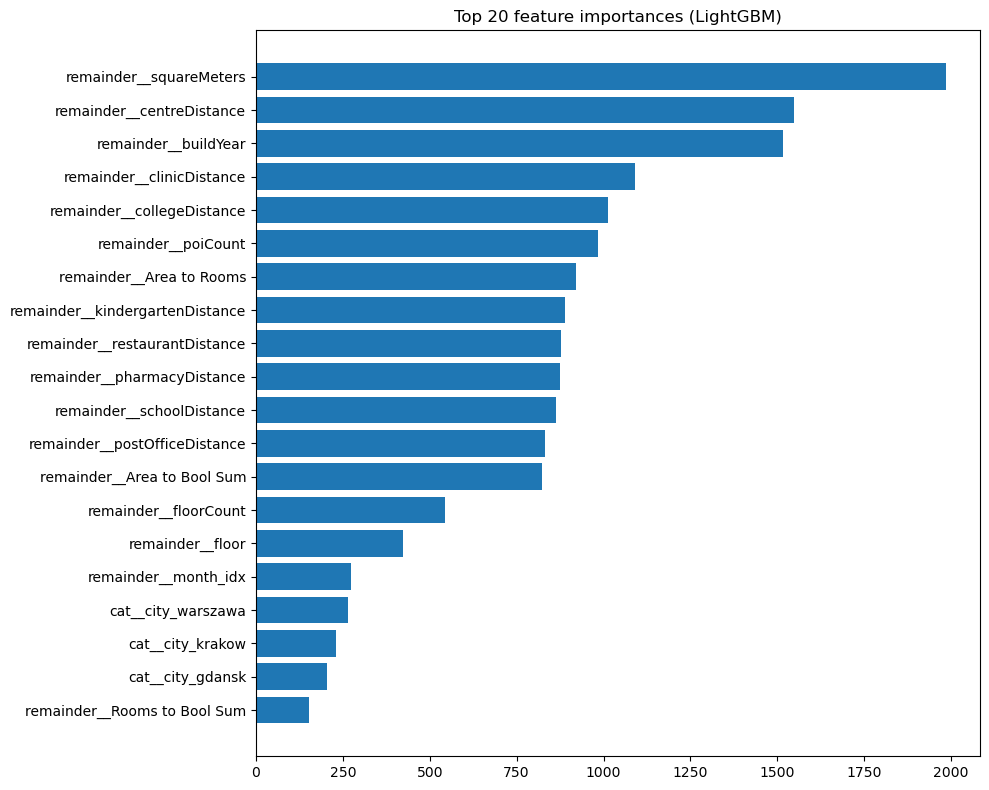

In [17]:
best_single = results.drop('Stacking (LGBM+CBR)').drop('Dummy (Baseline)')['RMSE'].idxmin()
print("Best single model:", best_single)

model_map = {'LightGBM': lgbm, 'CatBoost': cbr}
best_model = model_map[best_single]

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['regressor'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['feature'], imp_df['importance'])
ax.invert_yaxis()
ax.set_title(f'Top 20 feature importances ({best_single})')
plt.tight_layout()
plt.savefig('img/feature_importance.png', dpi=100)
plt.show()

## 11. Save models

In [18]:
model_dir = '../flats-model/'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(lgbm, model_dir + 'lgbm.joblib')
joblib.dump(cbr, model_dir + 'cbr.joblib')
joblib.dump(stack, model_dir + 'stack.joblib')
joblib.dump(knn_imputer, model_dir + 'knn_imputer.joblib')
joblib.dump({'elevator_mode': elevator_mode, 'month_to_idx': month_to_idx,
             'price_low': price_low, 'price_high': price_high,
             'area_low': area_low, 'area_high': area_high}, model_dir + 'preprocessing_meta.joblib')
print("Saved.")

Saved.


## 12. Prediction interface

`get_pred()` takes raw property characteristics and returns a predicted price, applying the same feature engineering and imputation used in training.

In [19]:
def get_pred(city, apt_type, square_meters, rooms, floor, floor_count, build_year,
             centre_distance, poi_count, school_distance, clinic_distance, post_office_distance,
             kindergarten_distance, restaurant_distance, college_distance, pharmacy_distance,
             ownership, building_material, condition, has_parking, has_balcony, has_elevator,
             has_security, has_storage, snapshot_month, model=None):
    if model is None:
        model = stack

    row = pd.DataFrame([{
        'city': city, 'type': apt_type, 'ownership': ownership,
        'buildingMaterial': building_material, 'condition': condition,
        'floor': floor, 'floorCount': floor_count, 'buildYear': build_year,
        'hasParkingSpace': has_parking, 'hasBalcony': has_balcony,
        'hasSecurity': has_security, 'hasStorageRoom': has_storage,
        'squareMeters': square_meters, 'rooms': rooms,
        'centreDistance': centre_distance, 'poiCount': poi_count,
        'schoolDistance': school_distance, 'clinicDistance': clinic_distance,
        'postOfficeDistance': post_office_distance, 'kindergartenDistance': kindergarten_distance,
        'restaurantDistance': restaurant_distance, 'collegeDistance': college_distance,
        'pharmacyDistance': pharmacy_distance,
        'hasElevator': has_elevator if has_elevator is not None else elevator_mode,
        'month_idx': month_to_idx.get(snapshot_month, max(month_to_idx.values()))
    }])

    row = engineer_features(row)
    row[knn_impute_cols] = knn_imputer.transform(row[knn_impute_cols])
    row = row[feature_cols]

    pred = model.predict(row)[0]
    return round(pred / 1000) * 1000

# Example call
example_price = get_pred(
    city='krakow', apt_type='blockOfFlats', square_meters=55, rooms=3,
    floor=4, floor_count=8, build_year=2005, centre_distance=3.5, poi_count=20,
    school_distance=0.3, clinic_distance=0.5, post_office_distance=0.4,
    kindergarten_distance=0.2, restaurant_distance=0.3, college_distance=1.0,
    pharmacy_distance=0.3, ownership='condominium', building_material='brick',
    condition='unknown', has_parking=True, has_balcony=True, has_elevator=True,
    has_security=False, has_storage=True, snapshot_month='2024-06'
)
print(f"Predicted price: {example_price:,.0f} PLN")

Predicted price: 897,000 PLN


## Summary

- **Time-based split** (train: Aug 2023–Apr 2024, test: May–Jun 2024) evaluates real forward generalization, not just random-split accuracy.
- **Outlier filtering and KNN imputation fit on train only** — fixes the leakage issue in the original project.
- **`month_idx` as an ordinal feature** lets the model extrapolate to unseen future months rather than treating each month as an unrelated category.
- See the results table above for the actual RMSE/MAE/MSLE comparison across DummyRegressor, GradientBoostingRegressor, LightGBM, CatBoost, and the Stacking ensemble on this run.

**Limitations carried forward / new:**
- Grids are intentionally small for runtime — widen them for a final model if compute allows.
- `month_idx` assumes a roughly linear/monotonic time trend; if the market reverses direction outside the training window, this feature could mislead the model — worth monitoring if this were deployed.
- ~11K test-period apartments were also seen (at a different price) during training — flagged above, not removed, since it reflects realistic deployment.